# Nb used to generate Activities for exps

In [ ]:
import os, sys, pickle
import pandas as pd
import numpy as np
from tqdm import tqdm
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)  # Set a wide width for display
pd.set_option('display.colheader_justify', 'center')  # Align column headers
pd.set_option('display.max_rows', 12)
sys.path.append('..') # Add parent folder to path
sys.path.append('../ABCVisualisation')
sys.path.append('../ABCVisualisation/ABCThermalPlots')
sys.path.append('../ABCVisualisation/ABCImaging')
from ABCVisualisation.ABCImaging.libimage import fetchImagesPaths
import matplotlib.pyplot as plt
from libActivity import computeSignatureActivity, plotActivities
from dask import compute
from dask.distributed import Client
from ABCVisualisation.InfluxDBInterface.libdb import download_data_DB
# Start a client using 3 agents of 3 CPUs each (total 9 CPUs)
# client = Client(n_workers=3, threads_per_worker=3)
client = Client()
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/worker-fdfd3_nc', purging
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/worker-cl33cu4u', purging
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/worker-qbo6y3ug', purging
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/worker-5c43wv4d', purging
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/scheduler-f2czbi92', purging
INFO:distributed.

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 12,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:65473,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:65489,Total threads: 3
Dashboard: http://127.0.0.1:65493/status,Memory: 8.00 GiB
Nanny: tcp://127.0.0.1:65476,


INFO:distributed.core:Event loop was unresponsive in Nanny for 19.05s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 19.05s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 19.06s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Nanny for 19.05s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 19.04s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause ti

## Congfiguration

In [2]:
hive_nb = 2
exp = 'aSensing1'  # 'aSensing1', 'aSensing2','aSensing3' or 'aSensing4'
#cutoff_time = pd.Timestamp('2024-10-29 01:00:00Z')  # Time to cut off the data for analysis
cutoff_time = None  # No cutoff

rootpath_imgs = '/Users/cyrilmonette/Library/CloudStorage/SynologyDrive-data/24.11_aSensing_OH/Images/'
img_freq = "1min" # Sampling frequency of images
duration = 30  # Minutes before and after signature to consider for activity computation

savePickle = True
verbose = False

## Main code

### Load all signatures of the exp

In [3]:
sigs_path = '../signatures'
all_sig_files = os.listdir(sigs_path)
all_sig_files = [s for s in all_sig_files if exp in s and f'sigs_{hive_nb}_' in s]
all_sig_files.sort()

all_sigs = pd.DataFrame(columns=["signature", "deltaT", "htr", "ihl"])
for sig_file in all_sig_files:
    with open(os.path.join(sigs_path, sig_file), 'rb') as f:
        sigs = pickle.load(f)
    if cutoff_time is not None:
        sigs = [s for s in sigs if s.ts_start < cutoff_time]
    deltaT = float(sig_file.split('_')[2])
    for sig in sigs:
        htr = sig.exp.heater.heater_num
        _ihl = sig.exp.heater.ihl
        all_sigs.loc[len(all_sigs)] = {"signature": sig,
                                        "deltaT": deltaT,
                                        "htr": htr,
                                        "ihl": _ihl}

print("Signatures loaded: ")
print(all_sigs.head())
print(f"Total signatures: {len(all_sigs)}")

Signatures loaded: 
                    signature                     deltaT htr   ihl  
0  <libaSensing.Signature object at 0x321f52510>    1.0   h00  upper
1  <libaSensing.Signature object at 0x106144a50>    1.0   h03  upper
2  <libaSensing.Signature object at 0x321f6d590>    1.0   h04  upper
3  <libaSensing.Signature object at 0x321f81ba0>    1.0   h07  upper
4  <libaSensing.Signature object at 0x321f823f0>    1.0   h08  upper
Total signatures: 2785


In [4]:
print("Signatures per heater per ihl: ")
for ihl in all_sigs['ihl'].unique():
    for htr in all_sigs['htr'].unique():
        print(f"  - {ihl} {htr}: {len(all_sigs[(all_sigs['ihl'] == ihl) & (all_sigs['htr'] == htr)])} signatures")

Signatures per heater per ihl: 
  - upper h00: 283 signatures
  - upper h03: 279 signatures
  - upper h04: 284 signatures
  - upper h07: 274 signatures
  - upper h08: 267 signatures
  - upper h01: 257 signatures
  - upper h02: 285 signatures
  - upper h05: 284 signatures
  - upper h09: 285 signatures
  - upper h06: 287 signatures


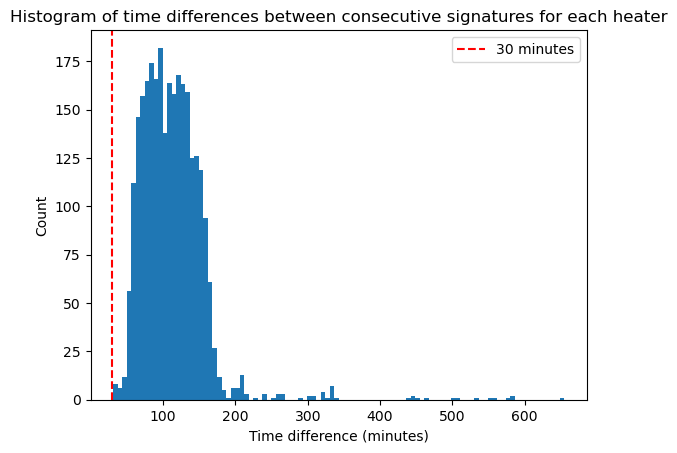

Number of time diffs < 30 minutes: 0 out of 2775


In [5]:
time_diffs = []
for _ihl in all_sigs['ihl'].unique():
    for _htr in all_sigs['htr'].unique():
        sigs = all_sigs.loc[(all_sigs['htr']==_htr) & (all_sigs['ihl']==_ihl)]
        sigs = sigs.loc[:,'signature'].to_list()
        # Sort the signatures by sig.ts_start
        sigs.sort(key=lambda s: s.ts_start)

        for i in range(1, len(sigs)):
            dt = (sigs[i].ts_start - sigs[i-1].ts_start).total_seconds() / 60.0  # in minutes
            time_diffs.append(dt)

plt.hist(time_diffs, bins=100)
plt.axvline(x=30, color='r', linestyle='--', label='30 minutes')
plt.title("Histogram of time differences between consecutive signatures for each heater")
plt.xlabel("Time difference (minutes)")
plt.ylabel("Count")
plt.legend()
plt.show()

print(f"Number of time diffs < 30 minutes: {sum(1 for dt in time_diffs if dt < 30)} out of {len(time_diffs)}")

### Create activity for the covered time

In [6]:
all_sig_ts = [sig.ts_start for sig in all_sigs.loc[:,'signature'].to_list()]

start_ts = min(all_sig_ts) - pd.Timedelta(minutes=duration) - pd.Timedelta(minutes=10)
stop_ts = max(all_sig_ts)  + pd.Timedelta(minutes=duration) + pd.Timedelta(minutes=10)
print(f"Will gather images between {start_ts} and {stop_ts} for hive {hive_nb} of experiment {exp}")
all_ts = pd.date_range(start=start_ts, end=stop_ts, freq=img_freq)
# Drop seconds from ts
all_ts = all_ts.map(lambda ts: ts.replace(second=0, microsecond=0))
imgs_paths = fetchImagesPaths(rootpath_imgs, all_ts, hive_nb, images_fill_limit=0, verbose=verbose)
print(imgs_paths)

Will gather images between 2024-10-28 13:10:33+01:00 and 2024-11-19 09:58:00+01:00 for hive 2 of experiment aSensing1
                                                 h2r1                                               h2r2                                               h2r3                                               h2r4                       
2024-10-28 13:10:00+01:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...
2024-10-28 13:11:00+01:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...
2024-10-28 13:12:00+01:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyril

In [7]:
# Count the number of Nones in each column of imgs_paths
none_counts = imgs_paths.isnull().sum()
print("Number of missing images per timestamp:")
print(none_counts[none_counts > 0])

Number of missing images per timestamp:
h2r1    8
h2r2    7
h2r3    8
h2r4    7
dtype: int64


In [8]:
def download_htr_tmp(_sig, duration):
    filters = {
        'measurement': ['htr'],
        'field': ['avg_temp'],
        'hive_num': _sig.exp.heater.hive_num,
        'actuator_instance': _sig.exp.heater.heater_num,
        'inhive_loc': _sig.exp.heater.ihl
    }
    data = download_data_DB("a_sensing", _sig.ts_start_pwm-pd.Timedelta(minutes=duration-1), _sig.ts_start_pwm+pd.Timedelta(minutes=duration), resolution=10, filters=filters)
    data.drop(columns=['_start', '_stop', '_field', '_measurement', 'actuator_instance', 'hive_num', 'inhive_loc', 'content', 'geo_loc', 'filling_density', 'board_id', 'serial_id', 'rpi_num', 'phys_loc', 'mcu_uuid'], inplace=True)
    data.loc[:, 'timeDelta'] = (data.index - _sig.ts_start_pwm).total_seconds() / 60.0  # in minutes
    # Remove duplicate index entries if any
    data = data[~data.index.duplicated(keep='first')]

    timeDelta = np.arange(-duration+1, duration+0.5, 0.5)
    data_filtered = pd.DataFrame({'timeDelta': timeDelta})
    for idx, td in data_filtered['timeDelta'].items():
        # Find the line in data with the closest timeDelta to idx
        closest_idx = (data['timeDelta'] - td).abs().idxmin()
        data_filtered.loc[idx, 'htr_tmp'] = data.loc[closest_idx, '_value']

    # Substract the temperature at timeDelta = 0 from all values
    temp_at_zero = data_filtered.loc[data_filtered['timeDelta'] == 0, 'htr_tmp'].values[0]
    data_filtered['htr_tmp'] = data_filtered['htr_tmp'] - temp_at_zero
    return data_filtered

In [9]:
activities = pd.DataFrame(columns=["ihl", "deltaT", "htr", "sig_activities", "htr_tmp"])
task_list = []
tasks_metadata = []
for _ihl in all_sigs['ihl'].unique():
    for _htr in all_sigs['htr'].unique():
        for _deltaT in all_sigs['deltaT'].unique():
            sigs = all_sigs.loc[(all_sigs['htr']==_htr) & (all_sigs['ihl']==_ihl) & (all_sigs['deltaT']==_deltaT)]
            sigs = sigs.loc[:,'signature'].to_list()
            
            for i, sig in enumerate(sigs):
                if i < len(sigs)-1:
                    next_sig_deltat = (sigs[i+1].ts_start - sig.ts_start).total_seconds() / 60.0
                    if next_sig_deltat < duration:
                        if verbose:
                            print(f"Skipping sig at {sig.ts_start} for ihl {_ihl}, htr {_htr}, deltaT {_deltaT} because next sig is in {next_sig_deltat} min < {duration} min")
                        continue
                sig_activities = computeSignatureActivity(sig, imgs_paths, duration)
                task_list.append(sig_activities)
                tasks_metadata.append({"ihl": _ihl,
                                       "deltaT": _deltaT,
                                       "htr": _htr})
                htr_tmp = download_htr_tmp(sig, duration)
                activities.loc[len(activities)] = {"ihl": _ihl,
                                                   "deltaT": _deltaT,
                                                   "htr": _htr,
                                                   "sig_activities": None,
                                                   "htr_tmp": htr_tmp
                                                   }

# Compute all activities using Dask
BATCH = 108
results = []
for i in tqdm(range(0, len(task_list), BATCH)):
    batch = task_list[i:i+BATCH]
    batch_results = compute(*batch)
    results.extend(batch_results)

# Reassemble results into activities DataFrame
for i, sig_activities in enumerate(results):
    activities.at[i, "sig_activities"] = sig_activities        

  0%|          | 0/26 [00:00<?, ?it/s]/opt/anaconda3/envs/aSensing/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 16.58 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
  4%|▍         | 1/26 [01:39<41:15, 99.03s/it]/opt/anaconda3/envs/aSensing/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 17.15 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
  8%|▊         | 2/26 [03:08<37:22, 93.43s/it]/opt/anaconda3/envs/aSen

In [10]:
print(len(activities["sig_activities"].iloc[0][0]))
activities

30


,ihl,deltaT,htr,sig_activities,htr_tmp
0,upper,1.0,h00,([<libActivity.Activity object at 0x33ae2cb30>...,timeDelta htr_tmp 0 -29.0 -0.0468...
1,upper,1.0,h00,([<libActivity.Activity object at 0x3403a3470>...,timeDelta htr_tmp 0 -29.0 0.3671...
2,upper,1.0,h00,([<libActivity.Activity object at 0x347037fb0>...,timeDelta htr_tmp 0 -29.0 0.1875...
3,upper,1.0,h00,([<libActivity.Activity object at 0x346a43bf0>...,timeDelta htr_tmp 0 -29.0 -0.0312...
4,upper,1.0,h00,([<libActivity.Activity object at 0x346b37bf0>...,timeDelta htr_tmp 0 -29.0 0.0156...
...,...,...,...,...,...
2780,upper,5.0,h06,([<libActivity.Activity object at 0x37e23bd10>...,timeDelta htr_tmp 0 -29.0 -0.3046...
2781,upper,5.0,h06,([<libActivity.Activity object at 0x3414c2150>...,timeDelta htr_tmp 0 -29.0 0.3750...
2782,upper,5.0,h06,([<libActivity.Activity object at 0x37fe63d10>...,timeDelta htr_tmp 0 -29.0 1.5468...
2783,upper,5.0,h06,([<libActivity.Activity object at 0x34774daf0>...,timeDelta htr_tmp 0 -29.0 0.8593...


In [11]:
print(sorted(activities[(activities["deltaT"]==3.0) & (activities['ihl']=='upper')].loc[:,"htr"].unique()))

['h00', 'h01', 'h02', 'h03', 'h04', 'h05', 'h06', 'h07', 'h08', 'h09']


### Saving to pickle

In [12]:
if savePickle:
    folder = "pickles/"
    filename = f'activities_{exp}_h{hive_nb}_{duration}min'
    if cutoff_time is not None:
        filename += f'_cutoff_{cutoff_time.strftime("%Y%m%dT%H%M")}'
    filename += '.pkl'
    print(f"Saving activities to {os.path.join(folder, filename)}")
    if os.path.exists(os.path.join(folder, filename)):
        raise FileExistsError(f"File {os.path.join(folder, filename)} already exists. Please change the filename or delete the existing file.")
    with open(os.path.join(folder, filename), 'wb') as f:
        pickle.dump(activities, f)
    print("Activities saved.")

Saving activities to pickles/activities_aSensing1_h2_30min.pkl
Activities saved.


### Plotting

In [20]:
print(len(activities.iloc[0]['sig_activities'][0]))

30


In [22]:
fig = plotActivities(activities, 5.0, "lower", common_y_axis=True)

IndexError: single positional indexer is out-of-bounds